In [166]:
import matplotlib.pyplot as plt
#import numpy as np
import pandas as pd
import math


names_bw=['time_msec', 'bw', 'op1', 'write_size', 'op2' ]
names_latency=['time_msec', 'latency', 'op2', 'write_size', 'op3']


### Uniform Random on HM-LS

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


2.6029486527707166
time_seconds     890.014542
bw                 4.379812
cumulative_gb      2.641797
dtype: float64


<Figure size 640x480 with 0 Axes>

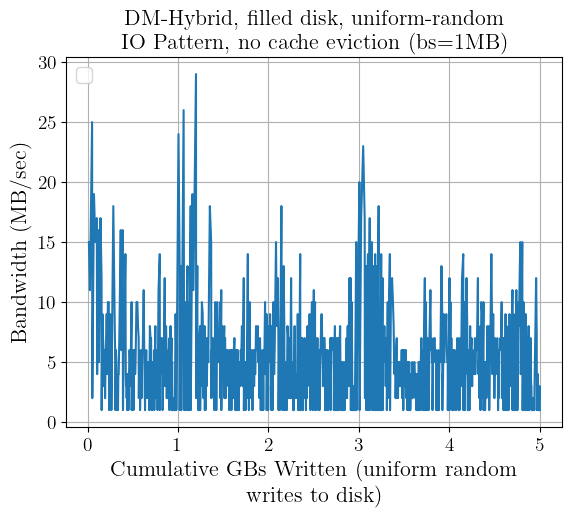

In [170]:
df_lat = pd.read_csv('/home/surbhi/measurements/worst_case/STL/1M/90-10-LBA/25Util/run2/lat_log_avg_lat.1.log', names=names_latency)
df_lat['time_msec'] = df_lat['time_msec'] - df_lat.iloc[0].time_msec
df_lat['latency'] = df_lat['latency'] / (10 ** 6) # convert latency nsec to msec
df_lat['ctime_msec'] = df_lat['time_msec'] + df_lat['latency']
df_lat['time_seconds'] = df_lat['ctime_msec'] / 1000  # Convert milliseconds to seconds
df_lat['time_seconds'] = df_lat['time_seconds'].astype(int)
df_binned = df_lat.groupby('time_seconds')['write_size'].sum().reset_index()
df_binned.columns = ['time_seconds', 'bw'] # write size in 1 second is the definition of bandwidth.
df_binned['bw'] = df_binned['bw'] / (1024 ** 2) # bytes to MB
df_binned['cumulative_gb'] = df_binned['bw'].cumsum() / (1024)
#df_binned['bw'] = df_binned['cumulative_gb'] * 1024/df_binned['time_seconds']
#print(df_binned.describe)
data = df_binned.iloc[-1]
print(data.cumulative_gb * 1024/data.time_seconds)
#Create the line plots
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots()
ax.plot(df_binned['cumulative_gb'], df_binned['bw'], linestyle='-')

# Add labels and title
plt.xlabel('Cumulative GBs Written (uniform random \n writes to disk)', fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel('Bandwidth (MB/sec)', fontsize=16)
plt.yticks(fontsize=14)

#data = df_binned.iloc[-1]
#print(data)
#avg_bw = (data.cumulative_gb/data.time_seconds) * 1024
avg_bw = df_binned.mean(axis=0)
print(avg_bw)
#avg_bw_str = str(round(avg_bw, 2)) + 'MB/sec'
#print(avg_bw)
#plt.axhline(y=avg_bw, color='r', linestyle='-', label='Overall Bandwidth: ' + avg_bw_str)
plt.title('DM-Hybrid, filled disk, uniform-random\nIO Pattern, no cache eviction (bs=1MB)', fontsize=16)
labels = plt.gca().get_xticklabels()
label_to_change = labels[-1].set_color('red')
plt.legend(loc='upper left', fontsize=14)

# Show the plot
plt.grid(True)  # Optionally, add grid lines
plt.savefig('/tmp/tmp.pdf', bbox_inches='tight')
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


1.761265909872721
time_seconds     1188.259882
bw                  4.306140
cumulative_gb       2.612111
dtype: float64


<Figure size 640x480 with 0 Axes>

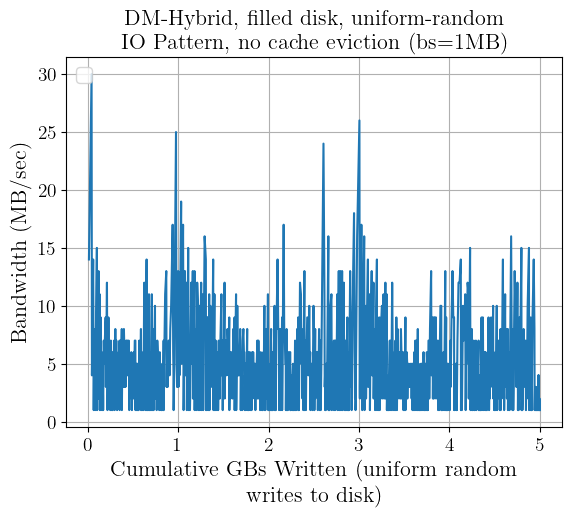

In [171]:
df_lat = pd.read_csv('/home/surbhi/measurements/worst_case/STL/1M/90-10-LBA/50Util/run2/lat_log_avg_lat.1.log', names=names_latency)
df_lat['time_msec'] = df_lat['time_msec'] - df_lat.iloc[0].time_msec
df_lat['latency'] = df_lat['latency'] / (10 ** 6) # convert latency nsec to msec
df_lat['ctime_msec'] = df_lat['time_msec'] + df_lat['latency']
df_lat['time_seconds'] = df_lat['ctime_msec'] / 1000  # Convert milliseconds to seconds
df_lat['time_seconds'] = df_lat['time_seconds'].astype(int)
df_binned = df_lat.groupby('time_seconds')['write_size'].sum().reset_index()
df_binned.columns = ['time_seconds', 'bw'] # write size in 1 second is the definition of bandwidth.
df_binned['bw'] = df_binned['bw'] / (1024 ** 2) # bytes to MB
df_binned['cumulative_gb'] = df_binned['bw'].cumsum() / (1024)
#df_binned['bw'] = df_binned['cumulative_gb'] * 1024/df_binned['time_seconds']
#print(df_binned.describe)
data = df_binned.iloc[-1]
print(data.cumulative_gb * 1024/data.time_seconds)
#Create the line plots
plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots()
ax.plot(df_binned['cumulative_gb'], df_binned['bw'], linestyle='-')

# Add labels and title
plt.xlabel('Cumulative GBs Written (uniform random \n writes to disk)', fontsize=16)
plt.xticks(fontsize=14)
plt.ylabel('Bandwidth (MB/sec)', fontsize=16)
plt.yticks(fontsize=14)

#data = df_binned.iloc[-1]
#print(data)
#avg_bw = (data.cumulative_gb/data.time_seconds) * 1024
avg_bw = df_binned.mean(axis=0)
print(avg_bw)
#avg_bw_str = str(round(avg_bw, 2)) + 'MB/sec'
#print(avg_bw)
#plt.axhline(y=avg_bw, color='r', linestyle='-', label='Overall Bandwidth: ' + avg_bw_str)
plt.title('DM-Hybrid, filled disk, uniform-random\nIO Pattern, no cache eviction (bs=1MB)', fontsize=16)
labels = plt.gca().get_xticklabels()
label_to_change = labels[-1].set_color('red')
plt.legend(loc='upper left', fontsize=14)

# Show the plot
plt.grid(True)  # Optionally, add grid lines
plt.savefig('/tmp/tmp.pdf', bbox_inches='tight')
plt.show()
